# PRAKTIKUM PENAMBANGAN DATA (PPD)
## MODUL 5: FORECASTING

* **Nama**: Januarsyah Akbar
* **NIM**: 24/535846/SV/24314
* **Kelas**: B2
* **Mata Kuliah**: Praktikum Penambangan Data (SVPL214610)
* **Program Studi**: D4 Teknologi Rekayasa Perangkat Lunak, Sekolah Vokasi UGM

---

## A. LANGKAH PERCOBAAN: BIKE SHARING FORECASTING
Dataset: [Bike Sharing Dataset](https://raw.githubusercontent.com/ganjar87/data_science_practice/main/bikesharing_day.csv)

### 1. Impor Library

In [1]:
# Import Library
import numpy as np
import pandas as pd
from math import sqrt
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from numpy import array
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from scipy.stats import pearsonr, kurtosis, skew
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split

print("Seluruh pustaka berhasil diimpor!")

Seluruh pustaka berhasil diimpor!


### 2. Import Dataset Bike Sharing

In [2]:
# Import Dataset
url_bike = 'https://raw.githubusercontent.com/ganjar87/data_science_practice/main/bikesharing_day.csv'
try:
    df = pd.read_csv(url_bike)
except Exception:
    df = pd.read_csv('data/bikesharing_day.csv')

df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,1/1/2011,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,1/2/2011,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,1/3/2011,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,1/4/2011,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,1/5/2011,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


### 3. Konversi Format Kolom Tanggal ke Datetime

In [3]:
# Change Data Format
df_ori = df.copy()
df_ori["date"] = pd.to_datetime(df_ori['dteday'])
print("Tipe data kolom 'date':", df_ori['date'].dtype)
df_ori['cnt'].iloc[:10]

Tipe data kolom 'date': datetime64[us]


0     985
1     801
2    1349
3    1562
4    1600
5    1606
6    1510
7     959
8     822
9    1321
Name: cnt, dtype: int64

### 4. Definisi Fungsi Sliding Window (`split_sequences`)
Fungsi ini bertugas memecah barisan data deret waktu menjadi pasangan fitur input lag ($t-n, \dots, t$) dan target prediksi masa depan ($t+k$).

In [4]:
# Function Definition Sliding Window
def split_sequences(sequences, n_steps_in, n_steps_out):
    X, y = list(), list()
    for i in range(len(sequences)):
        # find the end of this pattern
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # check if we are beyond the dataset
        if out_end_ix > len(sequences):
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequences[i:end_ix, :-1], sequences[out_end_ix - 1, -1]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

### 5. Definisi Fungsi Ekstraksi Fitur Statistik (`stats_features`)
Menambahkan 8 atribut statistik deskriptif pada setiap jendela observasi: minimum, maksimum, selisih (rentang), standar deviasi, mean, median, kurtosis, dan skewness.

In [5]:
# Function Definition Statistic Feature
def stats_features(input_data):
    inp = list()
    for i in range(len(input_data)):
        inp2 = list(input_data[i])
        min_v = float(np.min(inp2))
        max_v = float(np.max(inp2))
        diff = (max_v - min_v)
        std = float(np.std(inp2))
        mean = float(np.mean(inp2))
        median = float(np.median(inp2))
        kurt = float(kurtosis(inp2))
        sk = float(skew(inp2))
        inp2.extend([min_v, max_v, diff, std, mean, median, kurt, sk])
        inp.append(inp2)
    return np.array(inp)

### 6. Pemrosesan Data Deret Waktu (Sliding Window & Feature Engineering)

In [6]:
# Preprocessing
df_x = df_ori[['cnt', 'cnt']]
in_seq = df_x.astype(float).values

# Input 7 hari sebelumnya, output 1 hari berikutnya
n_steps_in, n_steps_out = 7, 1
X, y = split_sequences(in_seq, n_steps_in, n_steps_out)
n_input = X.shape[1] * X.shape[2]
X = X.reshape((X.shape[0], n_input))

# Pembagian data latih dan uji secara sekuensial (shuffle=False)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

# Penambahan fitur statistik
X_train = stats_features(X_train)
X_test = stats_features(X_test)

print("Dimensi X_train:", X_train.shape)
print("Dimensi X_test :", X_test.shape)
print("Dimensi y_train:", y_train.shape)
print("Dimensi y_test :", y_test.shape)

Dimensi X_train:

 (579, 15)
Dimensi X_test : (145, 15)
Dimensi y_train: (579,)
Dimensi y_test : (145,)


### 7. Inspeksi Hasil Transformasi Data

In [7]:
# Output from Data Transformation with Sliding Window Technique
print("Sample baris pertama X[0]:")
print(X[0])
print("\nTarget prediksi pertama y[0]:", y[0])

# Visualisasi ringkas deret waktu
df_new = df_ori[['date', 'cnt']].set_index('date')
df_new.head()

Sample baris pertama X[0]:
[ 985.  801. 1349. 1562. 1600. 1606. 1510.]

Target prediksi pertama y[0]: 959.0


,cnt
date,
2011-01-01,985
2011-01-02,801
2011-01-03,1349
2011-01-04,1562
2011-01-05,1600


### 8. Visualisasi Deret Waktu Data Asli Bike Sharing

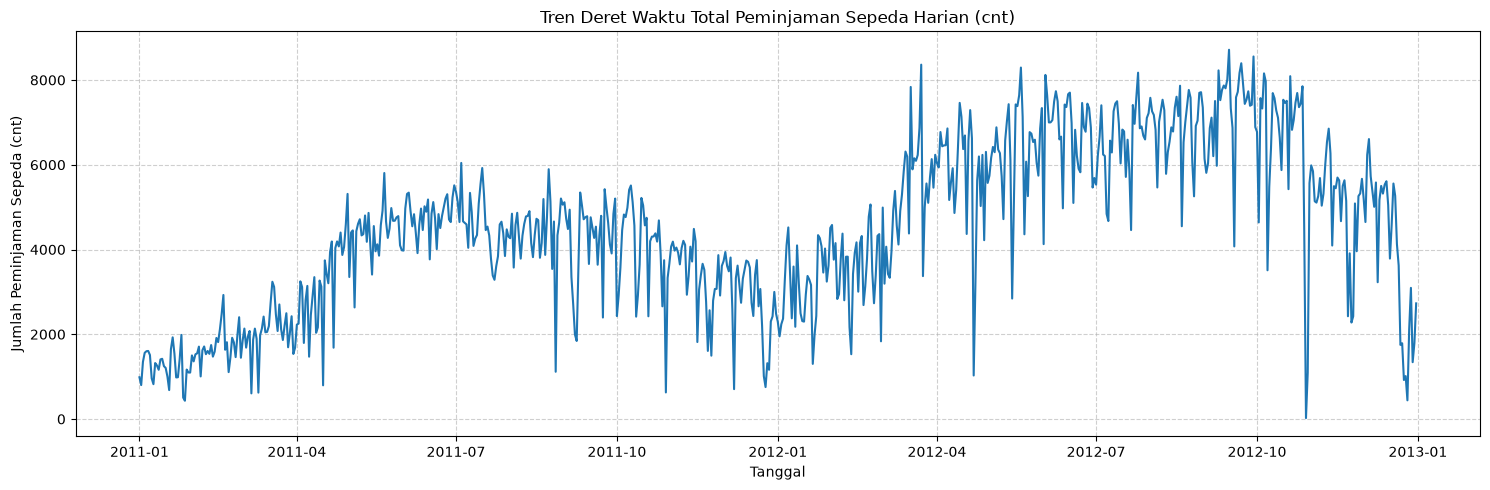

In [8]:
plt.figure(figsize=(15, 5))
plt.plot(df_new['cnt'], color='#1f77b4', linewidth=1.5)
plt.title('Tren Deret Waktu Total Peminjaman Sepeda Harian (cnt)', fontsize=12)
plt.xlabel('Tanggal', fontsize=10)
plt.ylabel('Jumlah Peminjaman Sepeda (cnt)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### 9. Definisi Fungsi Pemodelan Machine Learning (MLP, KNN, DT, RF)

In [9]:
# Multilayer Perceptron
def mlp(X_train, X_test, y_train, y_test):
    mlp_model = MLPRegressor(hidden_layer_sizes=(100, 100), max_iter=1000, random_state=42)
    mlp_model.fit(X_train, y_train)
    y_pred = mlp_model.predict(X_test)
    y_pred = np.round(y_pred, 0)
    rmse = sqrt(mean_squared_error(y_test, y_pred))
    corr, _ = pearsonr(y_test, y_pred)
    return rmse, corr, y_pred

# K-Nearest Neighbors
def knn(X_train, X_test, y_train, y_test):
    knn_model = KNeighborsRegressor()
    knn_model.fit(X_train, y_train)
    y_pred = knn_model.predict(X_test)
    y_pred = np.round(y_pred, 0)
    rmse = sqrt(mean_squared_error(y_test, y_pred))
    corr, _ = pearsonr(y_test, y_pred)
    return rmse, corr, y_pred

# Decision Tree Regressor
def dt(X_train, X_test, y_train, y_test):
    dt_model = DecisionTreeRegressor(random_state=42)
    dt_model.fit(X_train, y_train)
    y_pred = dt_model.predict(X_test)
    y_pred = np.round(y_pred, 0)
    rmse = sqrt(mean_squared_error(y_test, y_pred))
    corr, _ = pearsonr(y_test, y_pred)
    return rmse, corr, y_pred

# Random Forest Regressor
def rf(X_train, X_test, y_train, y_test):
    rf_model = RandomForestRegressor(random_state=42)
    rf_model.fit(X_train, y_train)
    y_pred = rf_model.predict(X_test)
    y_pred = np.round(y_pred, 0)
    rmse = sqrt(mean_squared_error(y_test, y_pred))
    corr, _ = pearsonr(y_test, y_pred)
    return rmse, corr, y_pred

### 10. Eksekusi Pelatihan dan Prediksi Model Percobaan

In [10]:
# Call Machine Learning Models
rmse_mlp, corr_mlp, y_pred_mlp = mlp(X_train, X_test, y_train, y_test)
rmse_knn, corr_knn, y_pred_knn = knn(X_train, X_test, y_train, y_test)
rmse_dt, corr_dt, y_pred_dt = dt(X_train, X_test, y_train, y_test)
rmse_rf, corr_rf, y_pred_rf = rf(X_train, X_test, y_train, y_test)

print("Seluruh model berhasil dilatih!")

Seluruh model berhasil dilatih!


### 11. Visualisasi Perbandingan Nilai Aktual vs Prediksi

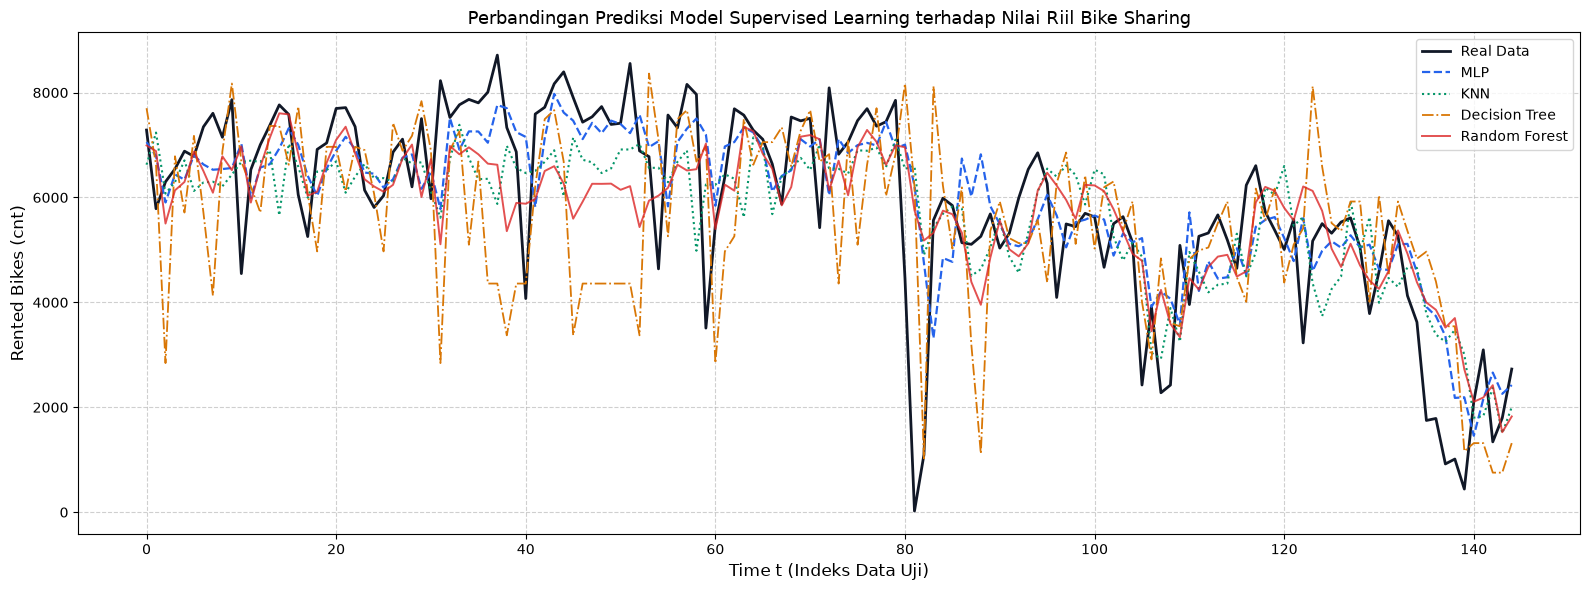

In [11]:
# Visualisasi Perbandingan
plt.figure(figsize=(16, 6))
plt.plot(y_test, label='Real Data', color='#111827', linewidth=2.0)
plt.plot(y_pred_mlp, label='MLP', color='#2563eb', linestyle='--', linewidth=1.6)
plt.plot(y_pred_knn, label='KNN', color='#059669', linestyle=':', linewidth=1.5)
plt.plot(y_pred_dt, label='Decision Tree', color='#d97706', linestyle='-.', linewidth=1.3)
plt.plot(y_pred_rf, label='Random Forest', color='#dc2626', linestyle='-', alpha=0.8, linewidth=1.4)

plt.xlabel('Time t (Indeks Data Uji)', fontsize=12)
plt.ylabel('Rented Bikes (cnt)', fontsize=12)
plt.title('Perbandingan Prediksi Model Supervised Learning terhadap Nilai Riil Bike Sharing', fontsize=13)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### 12. Evaluasi dan Rekapitulasi Model Percobaan

In [12]:
# Model Evaluation Summary
print('=========================================')
print('MLP')
print('RMSE : %.3f' % rmse_mlp)
print('Pearson correlation coefficient: %.3f' % corr_mlp)

print('-----------------------------------------')
print('KNN')
print('RMSE : %.3f' % rmse_knn)
print('Pearson correlation coefficient: %.3f' % corr_knn)

print('-----------------------------------------')
print('DT')
print('RMSE : %.3f' % rmse_dt)
print('Pearson correlation coefficient: %.3f' % corr_dt)

print('-----------------------------------------')
print('RF')
print('RMSE : %.3f' % rmse_rf)
print('Pearson correlation coefficient: %.3f' % corr_rf)
print('=========================================')

df_eval_bike = pd.DataFrame([
    {'Model': 'MLP', 'RMSE': rmse_mlp, 'Pearson R': corr_mlp},
    {'Model': 'KNN', 'RMSE': rmse_knn, 'Pearson R': corr_knn},
    {'Model': 'Decision Tree', 'RMSE': rmse_dt, 'Pearson R': corr_dt},
    {'Model': 'Random Forest', 'RMSE': rmse_rf, 'Pearson R': corr_rf},
])
df_eval_bike

MLP
RMSE : 1243.150
Pearson correlation coefficient: 0.751
-----------------------------------------
KNN
RMSE : 1357.710
Pearson correlation coefficient: 0.696
-----------------------------------------
DT
RMSE : 1854.465
Pearson correlation coefficient: 0.484
-----------------------------------------
RF
RMSE : 1324.452
Pearson correlation coefficient: 0.716


,Model,RMSE,Pearson R
0,MLP,1243.149590,0.750830
1,KNN,1357.709575,0.696141
2,Decision Tree,1854.465115,0.484298
3,Random Forest,1324.452085,0.716275


---
## B. TUGAS DAN ANALISIS: TESLA STOCK PRICE FORECASTING (2010 - 2020)
Dataset: [Tesla Stock Data from 2010 to 2020 (Kaggle timoboz)](https://www.kaggle.com/datasets/timoboz/tesla-stock-data-from-2010-to-2020/data)

### 1. Pemuatan dan Eksplorasi Dataset Saham Tesla

In [13]:
# Pemuatan Dataset Saham Tesla (TSLA)
url_tsla = 'https://raw.githubusercontent.com/vidvatabuch/Tesla-Stock-Analysis/master/TSLA.csv'
try:
    df_tsla = pd.read_csv(url_tsla)
except Exception:
    df_tsla = pd.read_csv('data/TSLA.csv')

df_tsla['Date'] = pd.to_datetime(df_tsla['Date'])
print("Dimensi dataset TSLA:", df_tsla.shape)
print("Pemeriksaan Missing Values:\n", df_tsla.isnull().sum())
df_tsla.head()

Dimensi dataset TSLA: (2416, 7)
Pemeriksaan Missing Values:
 Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


### Visualisasi Pergerakan Harga Saham Tesla (Close vs Open)

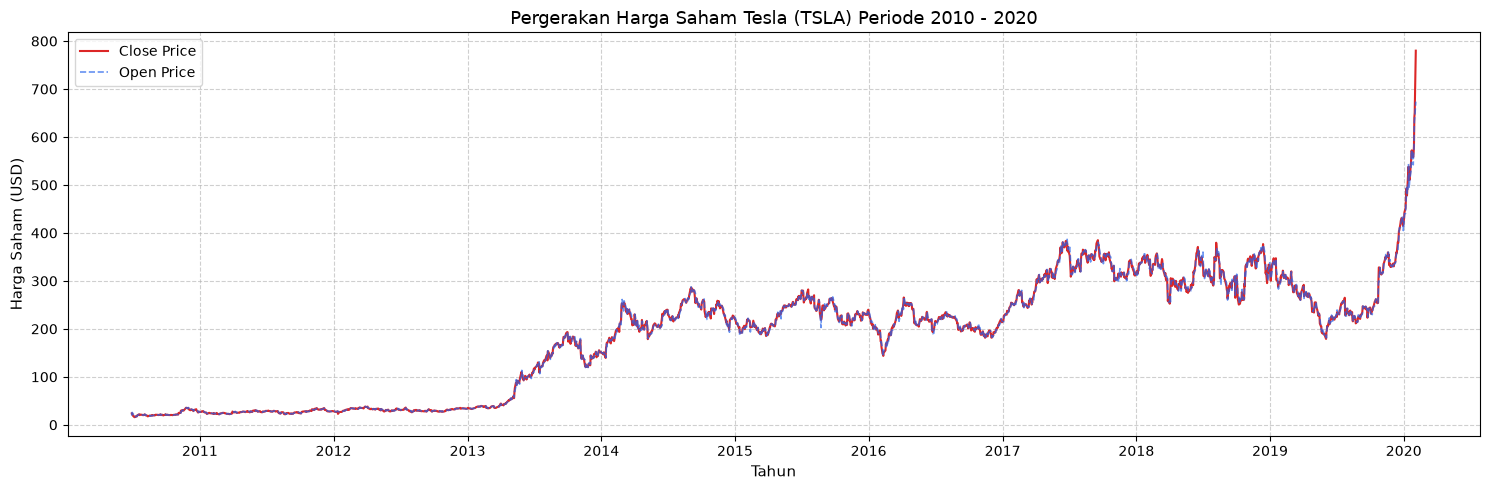

In [14]:
plt.figure(figsize=(15, 5))
plt.plot(df_tsla['Date'], df_tsla['Close'], label='Close Price', color='#dc2626', linewidth=1.5)
plt.plot(df_tsla['Date'], df_tsla['Open'], label='Open Price', color='#2563eb', linewidth=1.2, alpha=0.7, linestyle='--')
plt.title('Pergerakan Harga Saham Tesla (TSLA) Periode 2010 - 2020', fontsize=13)
plt.xlabel('Tahun', fontsize=11)
plt.ylabel('Harga Saham (USD)', fontsize=11)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### 2. Tugas 2: Forecasting Target Close 2 Hari ke Depan Berbasis Close 7 Hari Sebelumnya (Univariate)
* Input: Nilai `Close` 7 hari sebelumnya ($n_{steps\_in} = 7$)
* Output Target: Nilai `Close` 2 hari ke depan ($n_{steps\_out} = 2$, yaitu hari ke-$t+2$)

In [15]:
# Preprocessing Tugas 2 (Univariate)
seq_u = df_tsla[['Close', 'Close']].astype(float).values
n_in_tsla, n_out_tsla = 7, 2
X_u, y_u = split_sequences(seq_u, n_in_tsla, n_out_tsla)
X_u = X_u.reshape((X_u.shape[0], X_u.shape[1] * X_u.shape[2]))

# Split 80% train, 20% test tanpa pengacakan (shuffle=False)
X_u_tr, X_u_te, y_u_tr, y_u_te = train_test_split(
    X_u, y_u, test_size=0.2, random_state=42, shuffle=False
)

# Feature engineering statistik
X_u_tr = stats_features(X_u_tr)
X_u_te = stats_features(X_u_te)

print("Dimensi X_u_train:", X_u_tr.shape)
print("Dimensi X_u_test :", X_u_te.shape)
print("Dimensi y_u_train:", y_u_tr.shape)
print("Dimensi y_u_test :", y_u_te.shape)

Dimensi X_u_train: (1926, 15)
Dimensi X_u_test : (482, 15)
Dimensi y_u_train: (1926,)
Dimensi y_u_test : (482,)


### Pelatihan dan Evaluasi Model Tugas 2 (Univariate)

In [16]:
models_tsla = {
    'MLP': MLPRegressor(hidden_layer_sizes=(100, 100), max_iter=1000, random_state=42),
    'KNN': KNeighborsRegressor(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42)
}

preds_u = {}
results_u = []

for name, model in models_tsla.items():
    model.fit(X_u_tr, y_u_tr)
    pred = np.round(model.predict(X_u_te), 2)
    preds_u[name] = pred
    rmse = sqrt(mean_squared_error(y_u_te, pred))
    corr, _ = pearsonr(y_u_te, pred)
    results_u.append({
        'Model': name,
        'RMSE': rmse,
        'Pearson R': corr
    })

df_results_u = pd.DataFrame(results_u)
print("Rekapitulasi Evaluasi Tugas 2 (Univariate):")
df_results_u

Rekapitulasi Evaluasi Tugas 2 (Univariate):


,Model,RMSE,Pearson R
0,MLP,19.006650,0.967877
1,KNN,45.182823,0.799763
2,Decision Tree,47.232774,0.774912
3,Random Forest,44.995039,0.805014


### Visualisasi Hasil Prediksi Tugas 2 (Univariate)

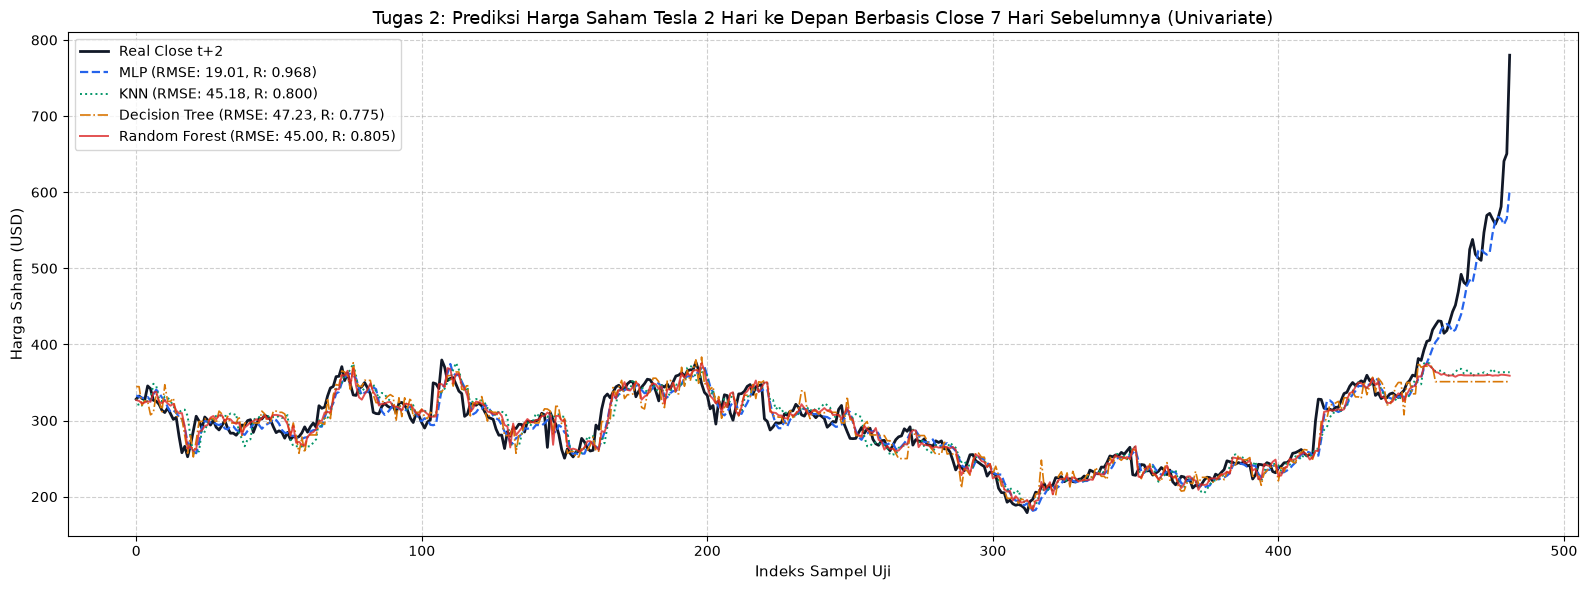

In [17]:
plt.figure(figsize=(16, 6))
plt.plot(y_u_te, label='Real Close t+2', color='#111827', linewidth=2.0)
plt.plot(preds_u['MLP'], label=f"MLP (RMSE: {results_u[0]['RMSE']:.2f}, R: {results_u[0]['Pearson R']:.3f})", color='#2563eb', linestyle='--', linewidth=1.6)
plt.plot(preds_u['KNN'], label=f"KNN (RMSE: {results_u[1]['RMSE']:.2f}, R: {results_u[1]['Pearson R']:.3f})", color='#059669', linestyle=':', linewidth=1.4)
plt.plot(preds_u['Decision Tree'], label=f"Decision Tree (RMSE: {results_u[2]['RMSE']:.2f}, R: {results_u[2]['Pearson R']:.3f})", color='#d97706', linestyle='-.', linewidth=1.2)
plt.plot(preds_u['Random Forest'], label=f"Random Forest (RMSE: {results_u[3]['RMSE']:.2f}, R: {results_u[3]['Pearson R']:.3f})", color='#dc2626', linestyle='-', alpha=0.8, linewidth=1.4)

plt.title('Tugas 2: Prediksi Harga Saham Tesla 2 Hari ke Depan Berbasis Close 7 Hari Sebelumnya (Univariate)', fontsize=13)
plt.xlabel('Indeks Sampel Uji', fontsize=11)
plt.ylabel('Harga Saham (USD)', fontsize=11)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### 3. Tugas 3: Forecasting Target Close 2 Hari ke Depan Berbasis Close & Open 7 Hari Sebelumnya (Multivariate)
* Input: Nilai `Close` dan `Open` 7 hari sebelumnya ($7 \times 2 = 14$ fitur dasar)
* Output Target: Nilai `Close` 2 hari ke depan ($n_{steps\_out} = 2$, yaitu hari ke-$t+2$)

In [18]:
# Preprocessing Tugas 3 (Multivariate)
seq_m = df_tsla[['Close', 'Open', 'Close']].astype(float).values
X_m, y_m = split_sequences(seq_m, n_in_tsla, n_out_tsla)
X_m = X_m.reshape((X_m.shape[0], X_m.shape[1] * X_m.shape[2]))

# Split 80% train, 20% test tanpa pengacakan
X_m_tr, X_m_te, y_m_tr, y_m_te = train_test_split(
    X_m, y_m, test_size=0.2, random_state=42, shuffle=False
)

# Feature engineering statistik
X_m_tr = stats_features(X_m_tr)
X_m_te = stats_features(X_m_te)

print("Dimensi X_m_train:", X_m_tr.shape)
print("Dimensi X_m_test :", X_m_te.shape)
print("Dimensi y_m_train:", y_m_tr.shape)
print("Dimensi y_m_test :", y_m_te.shape)

Dimensi X_m_train: (1926, 22)
Dimensi X_m_test : (482, 22)
Dimensi y_m_train: (1926,)
Dimensi y_m_test : (482,)


### Pelatihan dan Evaluasi Model Tugas 3 (Multivariate)

In [19]:
models_tsla_m = {
    'MLP': MLPRegressor(hidden_layer_sizes=(100, 100), max_iter=1000, random_state=42),
    'KNN': KNeighborsRegressor(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42)
}

preds_m = {}
results_m = []

for name, model in models_tsla_m.items():
    model.fit(X_m_tr, y_m_tr)
    pred = np.round(model.predict(X_m_te), 2)
    preds_m[name] = pred
    rmse = sqrt(mean_squared_error(y_m_te, pred))
    corr, _ = pearsonr(y_m_te, pred)
    results_m.append({
        'Model': name,
        'RMSE': rmse,
        'Pearson R': corr
    })

df_results_m = pd.DataFrame(results_m)
print("Rekapitulasi Evaluasi Tugas 3 (Multivariate):")
df_results_m

Rekapitulasi Evaluasi Tugas 3 (Multivariate):


,Model,RMSE,Pearson R
0,MLP,18.270305,0.970794
1,KNN,44.703425,0.805889
2,Decision Tree,45.663114,0.793360
3,Random Forest,44.775903,0.806723


### Visualisasi Hasil Prediksi Tugas 3 (Multivariate)

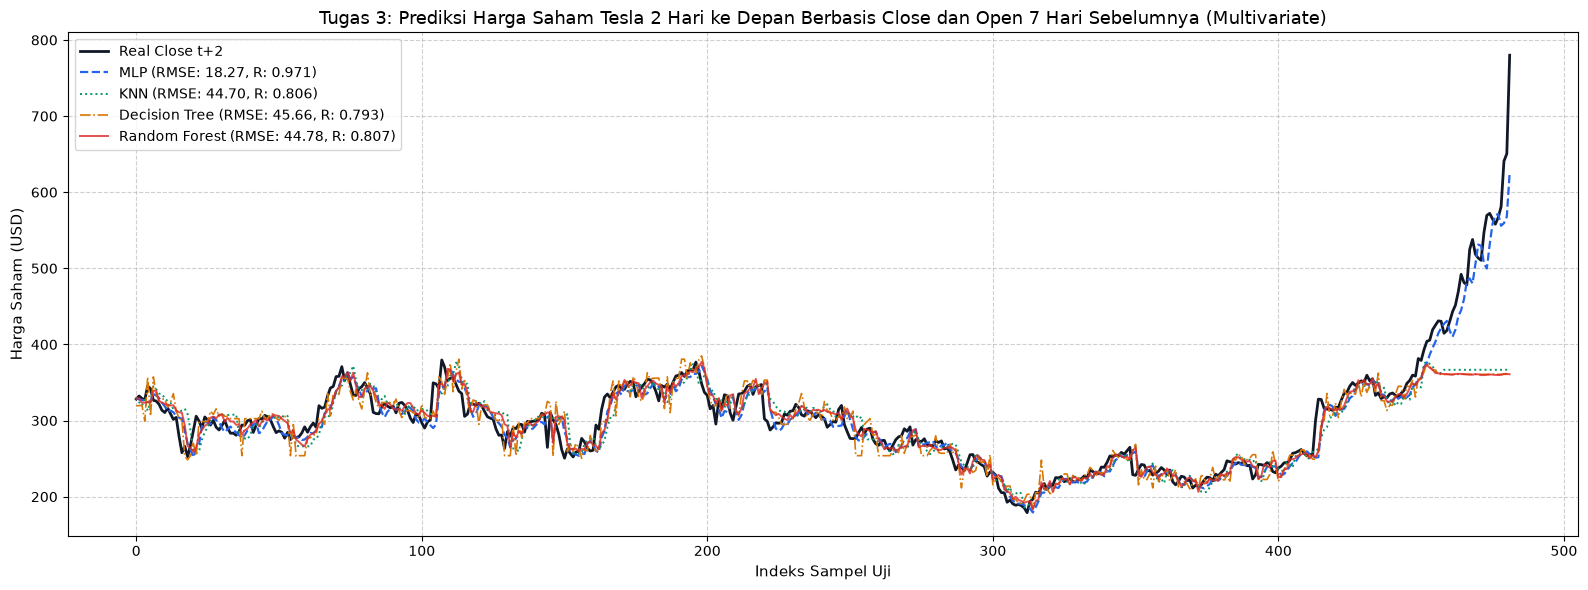

In [20]:
plt.figure(figsize=(16, 6))
plt.plot(y_m_te, label='Real Close t+2', color='#111827', linewidth=2.0)
plt.plot(preds_m['MLP'], label=f"MLP (RMSE: {results_m[0]['RMSE']:.2f}, R: {results_m[0]['Pearson R']:.3f})", color='#2563eb', linestyle='--', linewidth=1.6)
plt.plot(preds_m['KNN'], label=f"KNN (RMSE: {results_m[1]['RMSE']:.2f}, R: {results_m[1]['Pearson R']:.3f})", color='#059669', linestyle=':', linewidth=1.4)
plt.plot(preds_m['Decision Tree'], label=f"Decision Tree (RMSE: {results_m[2]['RMSE']:.2f}, R: {results_m[2]['Pearson R']:.3f})", color='#d97706', linestyle='-.', linewidth=1.2)
plt.plot(preds_m['Random Forest'], label=f"Random Forest (RMSE: {results_m[3]['RMSE']:.2f}, R: {results_m[3]['Pearson R']:.3f})", color='#dc2626', linestyle='-', alpha=0.8, linewidth=1.4)

plt.title('Tugas 3: Prediksi Harga Saham Tesla 2 Hari ke Depan Berbasis Close dan Open 7 Hari Sebelumnya (Multivariate)', fontsize=13)
plt.xlabel('Indeks Sampel Uji', fontsize=11)
plt.ylabel('Harga Saham (USD)', fontsize=11)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### 4. Analisis Komparatif: Univariate vs Multivariate

In [21]:
df_compare = pd.DataFrame({
    'Model': [r['Model'] for r in results_u],
    'RMSE Univariate (USD)': [r['RMSE'] for r in results_u],
    'RMSE Multivariate (USD)': [r['RMSE'] for r in results_m],
    'Pearson R Univariate': [r['Pearson R'] for r in results_u],
    'Pearson R Multivariate': [r['Pearson R'] for r in results_m]
})
df_compare['Penurunan RMSE (USD)'] = df_compare['RMSE Univariate (USD)'] - df_compare['RMSE Multivariate (USD)']
df_compare

,Model,RMSE Univariate (USD),RMSE Multivariate (USD),Pearson R Univariate,Pearson R Multivariate,Penurunan RMSE (USD)
0,MLP,19.006650,18.270305,0.967877,0.970794,0.736345
1,KNN,45.182823,44.703425,0.799763,0.805889,0.479397
2,Decision Tree,47.232774,45.663114,0.774912,0.793360,1.569660
3,Random Forest,44.995039,44.775903,0.805014,0.806723,0.219136


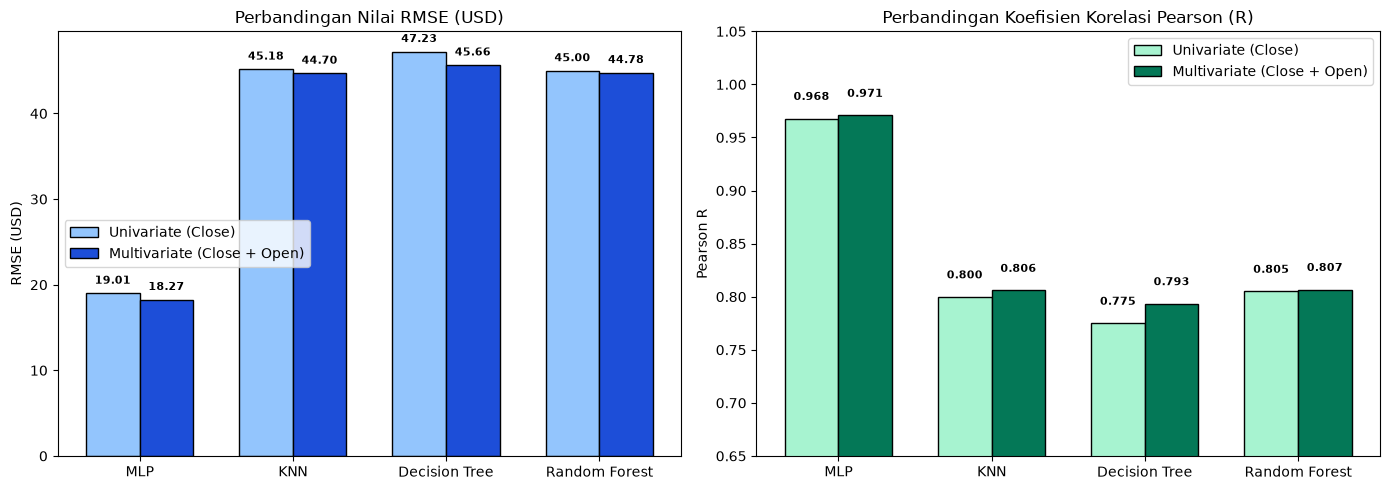

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
x_pos = np.arange(len(df_compare))
width = 0.35

# RMSE
b1 = ax1.bar(x_pos - width/2, df_compare['RMSE Univariate (USD)'], width=width, label='Univariate (Close)', color='#93c5fd', edgecolor='black')
b2 = ax1.bar(x_pos + width/2, df_compare['RMSE Multivariate (USD)'], width=width, label='Multivariate (Close + Open)', color='#1d4ed8', edgecolor='black')
ax1.set_title('Perbandingan Nilai RMSE (USD)')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(df_compare['Model'])
ax1.set_ylabel('RMSE (USD)')
ax1.legend()
for b in b1 + b2:
    h = b.get_height()
    ax1.text(b.get_x() + b.get_width()/2, h + 0.8, f'{h:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Pearson R
b3 = ax2.bar(x_pos - width/2, df_compare['Pearson R Univariate'], width=width, label='Univariate (Close)', color='#a7f3d0', edgecolor='black')
b4 = ax2.bar(x_pos + width/2, df_compare['Pearson R Multivariate'], width=width, label='Multivariate (Close + Open)', color='#047857', edgecolor='black')
ax2.set_title('Perbandingan Koefisien Korelasi Pearson (R)')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(df_compare['Model'])
ax2.set_ylabel('Pearson R')
ax2.set_ylim(0.65, 1.05)
ax2.legend()
for b in b3 + b4:
    h = b.get_height()
    ax2.text(b.get_x() + b.get_width()/2, h + 0.015, f'{h:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

### 5. Analisis Pemilihan Model Terbaik dan Fenomena Ekstrapolasi

Berdasarkan komparasi performa pada tabel dan grafik di atas:
* **Model Terbaik**: **Multilayer Perceptron (MLP Regressor) pada skenario Multivariate**.
  * Nilai RMSE terendah: **18.27 USD** (jauh lebih presisi dibandingkan Random Forest 44.78 USD, KNN 44.70 USD, dan Decision Tree 45.66 USD).
  * Koefisien korelasi tertinggi: **0.9708** (sangat mendekati angka sempurna 1.0, membuktikan bahwa prediksi model selaras rapat dengan fluktuasi riil pasar saham).

**Mengapa MLP Jauh Mengungguli Decision Tree dan Random Forest pada Kasus Saham Ini?**
1. **Keterbatasan Ekstrapolasi Model Pohon Keputusan**:
   Model berbasis partisi ruang sampel (Decision Tree, Random Forest) maupun pendekatan tetangga terdekat (KNN) tidak dapat memprediksi nilai di luar rentang nilai maksimum yang pernah ditemui selama pelatihan. Ketika harga saham Tesla mengalami lonjakan signifikan pada periode akhir 2019 hingga awal 2020 (mencapai rentang 400 hingga 780 USD), model pohon mengalami saturasi (plafon) dan hanya mampu memprediksi rata-rata nilai tertinggi dari data latih (sekitar 350 hingga 380 USD).
2. **Kekuatan Representasi Fungsi Non-Linear pada Jaringan Syaraf Tiruan (MLP)**:
   MLP memodelkan hubungan fungsional melalui kombinasi linear bobot sinaptik dan fungsi aktivasi non-linear (ReLU). Arsitektur multi-lapisan memungkinkan jaringan memetakan gradien pertumbuhan deret waktu dan mengekstrapolasikan pola tren kenaikan harga ke wilayah nilai baru yang belum pernah muncul pada fase pelatihan.
3. **Pengaruh Penambahan Fitur Harga Pembukaan (Open Price)**:
   Penambahan riwayat harga pembukaan harian memberikan sinyal momentum volatilitas intraday yang melengkapi informasi harga penutupan. Terbukti pada seluruh model yang diuji, penambahan fitur Open secara konsisten memangkas nilai galat RMSE dan meningkatkan koefisien korelasi Pearson.